<a href="https://colab.research.google.com/github/CogitoNTNU/GymbroAI/blob/BLE/GymBro_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#----------------- GymBro AI -----------------

##Exercise Recognition - Training & Full Int8 Quantization Pipeline
Trains a neural network on IMU data and exports a fully int8-quantized
TFLite model suitable for Arduino Nano 33 BLE Sense + TFLite Micro.

Key: Uses FULL INTEGER quantization (not dynamic range) so that ALL
operations run in int8 on the microcontroller — no float computation,
no BLE interrupt conflicts, and proper TFLite Micro kernel support.



## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [ ]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow==2.19.0

# 0. Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag `exercise_name.csv` files from your computer to the tab to upload them into colab.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
import struct

# ─── Configuration ───────────────────────────────────────────────
NUM_SAMPLES = 119          # Time steps per gesture window
NUM_FEATURES = 6           # aX, aY, aZ, gX, gY, gZ
EPOCHS = 500
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Normalization ranges (must match Arduino code)
ACCEL_MIN, ACCEL_MAX = -4.0, 4.0
GYRO_MIN, GYRO_MAX = -2000.0, 2000.0

# Exercise definitions — add new exercises here and correct file name
EXERCISES = {
    "bicep_curl":      "bicep_curl.csv",
    "shoulder_press":  "shoulder_press.csv",
    "rows": "rows.csv",
}

GESTURE_NAMES = list(EXERCISES.keys())
NUM_CLASSES = len(GESTURE_NAMES)

print(f"Training {NUM_CLASSES}-class model: {GESTURE_NAMES}")

Training 3-class model: ['bicep_curl', 'shoulder_press', 'rows']


# 1. Load & Normalize Data

In [ ]:
def normalize_sample(data):
    """Normalize IMU data to [0, 1] — same formula as Arduino code."""
    normed = np.copy(data).astype(np.float32)
    # Accelerometer columns (0, 1, 2)
    normed[:, 0:3] = (normed[:, 0:3] - ACCEL_MIN) / (ACCEL_MAX - ACCEL_MIN)
    # Gyroscope columns (3, 4, 5)
    normed[:, 3:6] = (normed[:, 3:6] - GYRO_MIN) / (GYRO_MAX - GYRO_MIN)
    return np.clip(normed, 0.0, 1.0)


def load_and_window(csv_path, label_index):
    """Load CSV, split into windows of NUM_SAMPLES, normalize."""
    df = pd.read_csv(csv_path)
    data = df.values.astype(np.float32)

    windows = []
    labels = []
    # Non-overlapping windows
    for start in range(0, len(data) - NUM_SAMPLES + 1, NUM_SAMPLES):
        window = data[start:start + NUM_SAMPLES]
        window = normalize_sample(window)
        windows.append(window.flatten())  # Shape: (714,)
        labels.append(label_index)

    print(f"  {csv_path}: {len(windows)} windows from {len(data)} samples")
    return windows, labels


all_windows = []
all_labels = []

for i, (name, csv_file) in enumerate(EXERCISES.items()):
    path = Path("/content/"+csv_file)
    if not path.exists():
        # Try project directory
        path = Path(f"/mnt/project/{csv_file}")
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {csv_file}")

    windows, labels = load_and_window(str(path), i)
    all_windows.extend(windows)
    all_labels.extend(labels)

X = np.array(all_windows, dtype=np.float32)  # (N, 714)
y = np.array(all_labels, dtype=np.int32)

# Shuffle
indices = np.arange(len(X))
np.random.seed(42)
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

print(f"\nTotal dataset: {len(X)} samples, {NUM_CLASSES} classes")
print(f"Input shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

  /content/bicep_curl.csv: 19 windows from 2361 samples
  /content/shoulder_press.csv: 18 windows from 2192 samples
  /content/rows.csv: 19 windows from 2360 samples

Total dataset: 56 samples, 3 classes
Input shape: (56, 714)
Class distribution: [19 18 19]


# 2. Build & Train Model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(NUM_SAMPLES * NUM_FEATURES,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1
)

val_acc = max(history.history['val_accuracy'])
print(f"\nBest validation accuracy: {val_acc:.2%}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        45,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,939 (187.26 KB)

 Trainable params: 47,939 (187.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.3182 - loss: 1.1253 - val_accuracy: 0.5833 - val_loss: 1.0601
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4773 - loss: 1.0303 - val_accuracy: 0.3333 - val_loss: 1.0458
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5227 - loss: 1.0171 - val_accuracy: 0.6667 - val_loss: 0.9987
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6136 - loss: 0.9532 - val_accuracy: 0.2500 - val_loss: 1.0413
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4545 - loss: 1.0252 - val_accuracy: 0.2500 - val_loss: 1.0969
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3864 - loss: 1.1106 - val_accuracy: 0.5833 - val_loss: 0.9954
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4773 - loss: 0.9963 - val_accuracy: 0.3333 - val_loss: 0.9913
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4091 - loss: 1.0168 - val_accuracy: 0.5833 - val_loss

# 3. Verify Float Model

### Graph the loss

Graph the loss to see when the model stops improving.

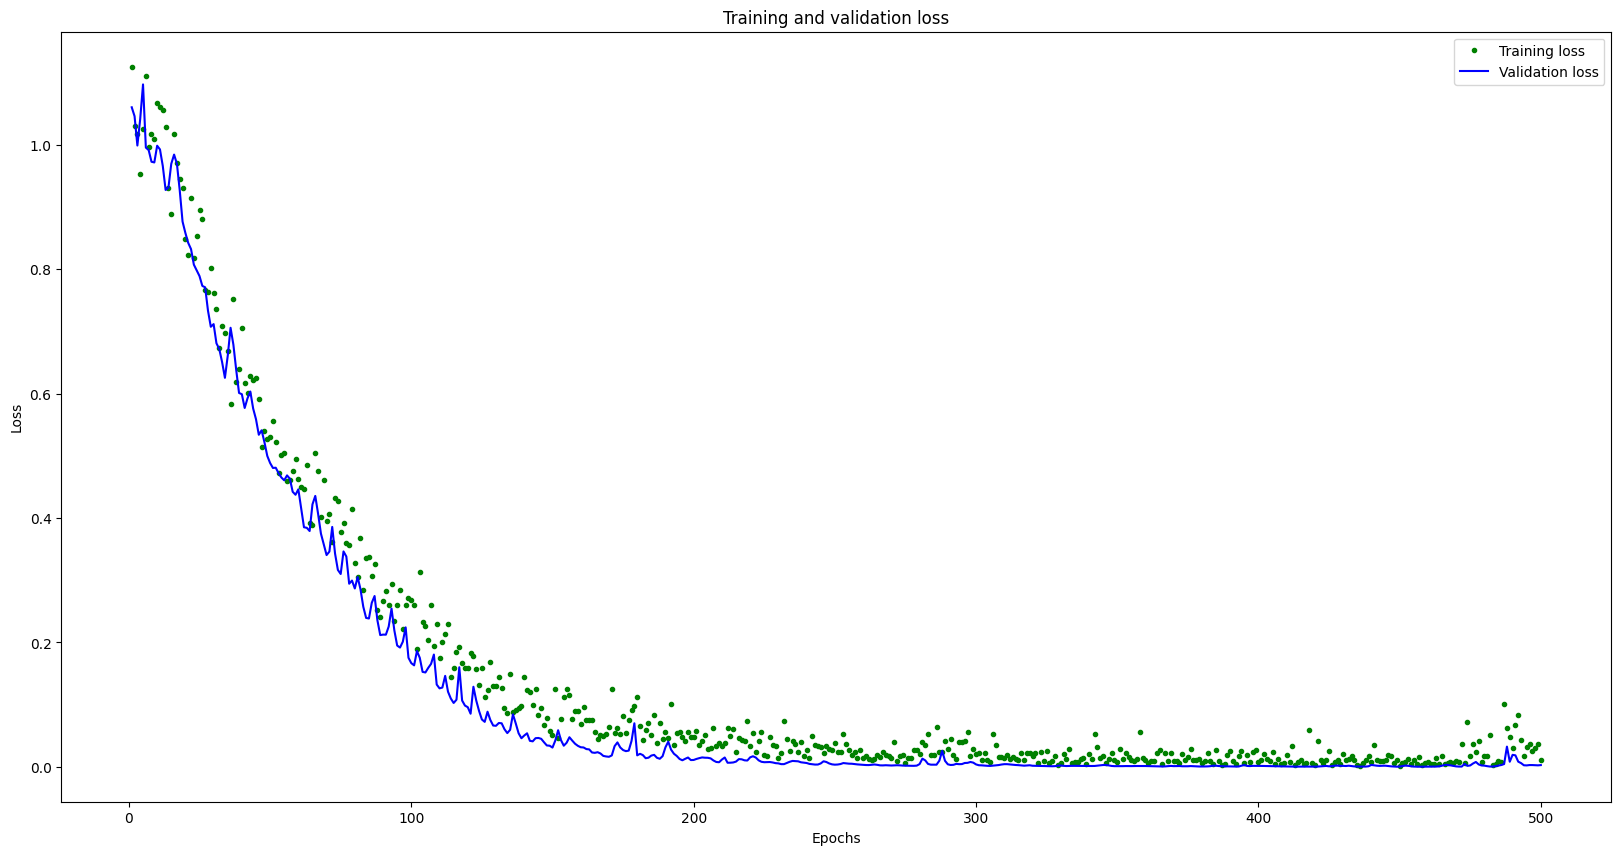

[20.0, 10.0]


In [ ]:
import matplotlib.pyplot as plt
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

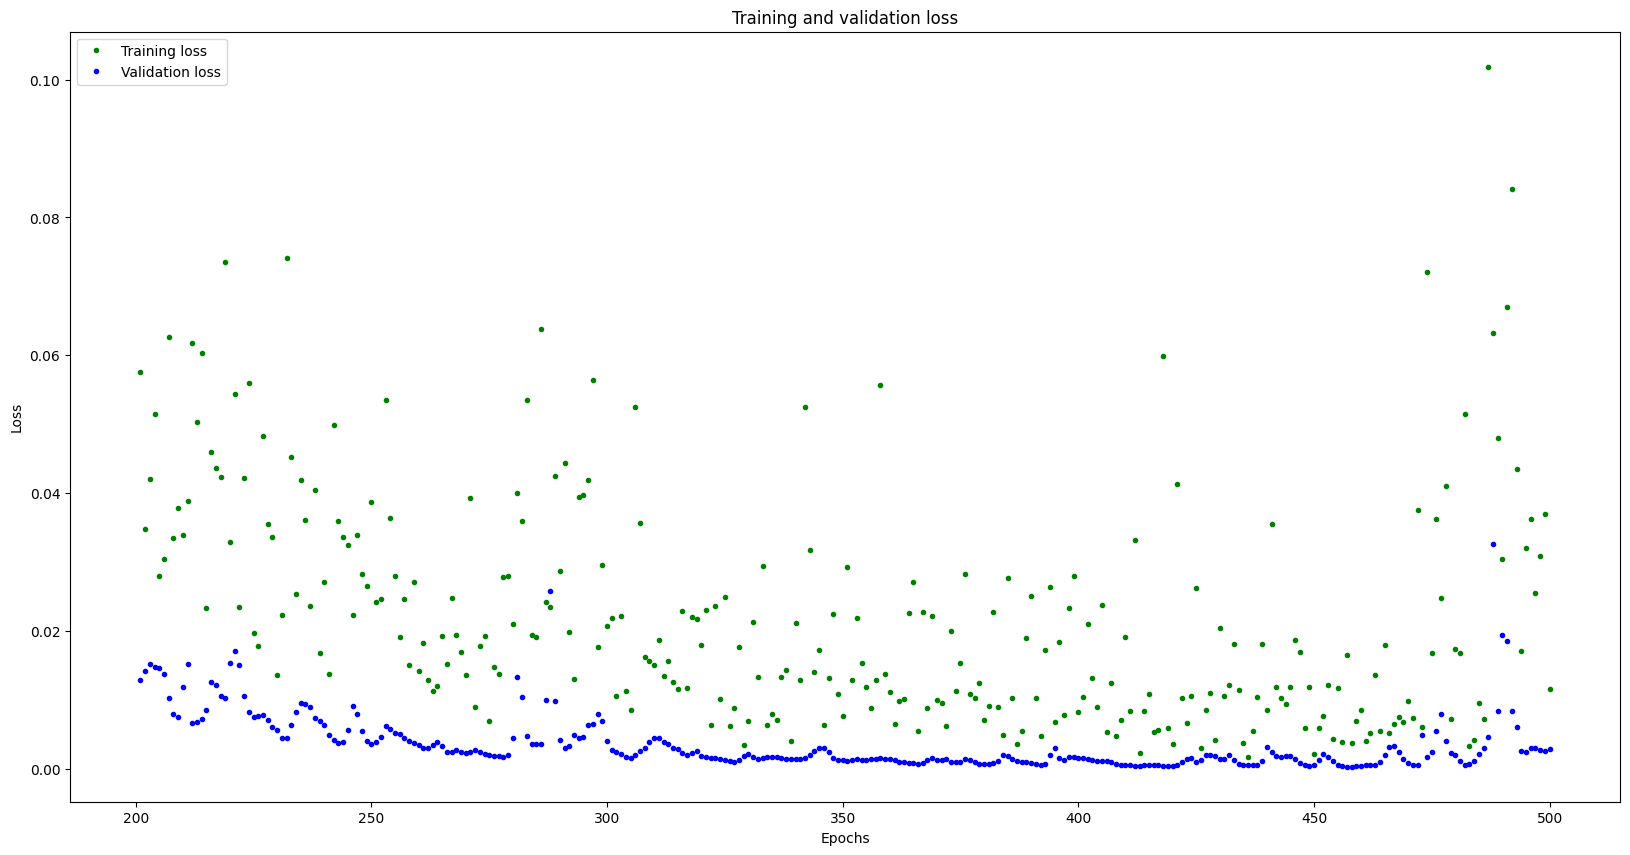

In [ ]:
# graph the loss again skipping a bit of the start
SKIP = 200
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 4. Full Integer Quantization

In [ ]:
print("\n--- Full Int8 Quantization ---")

# Representative dataset generator (REQUIRED for full int8 quantization)
def representative_dataset():
    """Yields representative input samples for calibration."""
    # Use a subset of training data for calibration
    cal_indices = np.random.choice(len(X), min(100, len(X)), replace=False)
    for i in cal_indices:
        sample = X[i:i+1].astype(np.float32)
        yield [sample]

# Convert with FULL integer quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
# Force all ops to int8 (input/output stay float32 for convenience)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32   # Keep float I/O for easy Arduino use
converter.inference_output_type = tf.float32

tflite_model = converter.convert()
print(f"Quantized model size: {len(tflite_model):,} bytes")

# Save .tflite file
tflite_path = "model_int8.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"Saved: {tflite_path}")



--- Full Int8 Quantization ---
Saved artifact at '/tmp/tmp3i8vzmmz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='keras_tensor_30')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133096970499088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133096970496784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133096970494672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133096970498704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133096970499664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133096970499856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized model size: 53,456 bytes
Saved: model_int8.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


# 5. Verify Quantized Model

In [ ]:
print("\n--- Quantized Model Verification ---")
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input:  shape={input_details[0]['shape']}, dtype={input_details[0]['dtype']}")
print(f"Output: shape={output_details[0]['shape']}, dtype={output_details[0]['dtype']}")

# Test predictions with quantized model
print("\nQuantized model predictions:")
for i in range(min(5, len(X))):
    interpreter.set_tensor(input_details[0]['index'], X[i:i+1])
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]
    pred_class = np.argmax(output)
    confidence = output[pred_class]
    true_class = y[i]
    match = "✓" if pred_class == true_class else "✗"
    print(f"  {match} Sample {i}: predicted={GESTURE_NAMES[pred_class]} "
          f"({confidence:.2%}), true={GESTURE_NAMES[true_class]}")

# Full accuracy test
correct = 0
for i in range(len(X)):
    interpreter.set_tensor(input_details[0]['index'], X[i:i+1])
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]
    if np.argmax(output) == y[i]:
        correct += 1
quant_acc = correct / len(X)
print(f"\nQuantized model accuracy: {quant_acc:.2%} (on training data)")


--- Quantized Model Verification ---
Input:  shape=[  1 714], dtype=<class 'numpy.float32'>
Output: shape=[1 3], dtype=<class 'numpy.float32'>

Quantized model predictions:
  ✓ Sample 0: predicted=bicep_curl (99.61%), true=bicep_curl
  ✓ Sample 1: predicted=bicep_curl (99.61%), true=bicep_curl
  ✓ Sample 2: predicted=shoulder_press (99.61%), true=shoulder_press
  ✓ Sample 3: predicted=bicep_curl (99.61%), true=bicep_curl
  ✓ Sample 4: predicted=shoulder_press (99.61%), true=shoulder_press

Quantized model accuracy: 100.00% (on training data)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


# 6. Generate Arduino Header File

In [ ]:
print("\n--- Generating Arduino Header ---")

header_path = "model_int8.h"
with open(header_path, 'w') as f:
    f.write('// Auto-generated — full int8 quantized TFLite model\n')
    f.write(f'// Model size: {len(tflite_model):,} bytes\n')
    f.write(f'// Classes: {GESTURE_NAMES}\n')
    f.write(f'// Input: ({NUM_SAMPLES} × {NUM_FEATURES}) = {NUM_SAMPLES * NUM_FEATURES} float32 values\n')
    f.write(f'// Quantized accuracy: {quant_acc:.2%}\n\n')
    f.write('#ifndef MODEL_INT8_H\n')
    f.write('#define MODEL_INT8_H\n\n')
    f.write(f'constexpr int kNumSamples = {NUM_SAMPLES};\n')
    f.write(f'constexpr int kNumFeatures = {NUM_FEATURES};\n')
    f.write(f'constexpr int kNumClasses = {NUM_CLASSES};\n\n')

    # Gesture names array
    f.write('const char* kGestureNames[] = {\n')
    for name in GESTURE_NAMES:
        f.write(f'  "{name}",\n')
    f.write('};\n\n')

    # Model bytes — aligned for ARM
    f.write(f'alignas(16) const unsigned char g_model[] = {{\n')
    for i in range(0, len(tflite_model), 12):
        f.write('  ')
        chunk = tflite_model[i:i+12]
        f.write(', '.join(f'0x{b:02x}' for b in chunk))
        if i + 12 < len(tflite_model):
            f.write(',')
        f.write('\n')
    f.write('};\n')
    f.write(f'const unsigned int g_model_len = {len(tflite_model)};\n\n')
    f.write('#endif  // MODEL_INT8_H\n')

print(f"Saved: {header_path}")
print(f"Header file size: {Path(header_path).stat().st_size:,} bytes")

# Copy to outputs
#import shutil
#shutil.copy(header_path, f"/content/{header_path}")
#shutil.copy(tflite_path, f"/content/{tflite_path}")

print("\n=== Done ===")
print(f"Model: {tflite_path} ({len(tflite_model):,} bytes)")
print(f"Header: {header_path}")
print(f"Classes: {GESTURE_NAMES}")
print(f"Accuracy: {quant_acc:.2%}")


--- Generating Arduino Header ---
Saved: model_int8.h
Header file size: 330,191 bytes

=== Done ===
Model: model_int8.tflite (53,456 bytes)
Header: model_int8.h
Classes: ['bicep_curl', 'shoulder_press', 'rows']
Accuracy: 100.00%
